# (16) white noise analysis w/ best fit: (16, 20.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from utils.animation import show_movie
from analysis.sta import compute_sta


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Load trainer

In [3]:
model_name = 'vH16_t-16_z-[512]_<grad|lin>'
fit_name = 'b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_15,09:26)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)

In [19]:
feeder_kws = dict(
    npix=16,
    #
    n_repeats=1,
    batch_size=500,
    noise_sigma=1.0,
    #
    device=device,
    flatten=True,
)

In [20]:
%%time


warmup = 10 * feeder_kws['n_repeats']
total_timepoints = 2000 + warmup

total_runs = 100
n_lags = 80

sta_unnormalized_all = {}
n_spks_all = {}

for i in tqdm(range(total_runs)):
    # get feeder
    feeder = FEEDER_CLASSES['white-noise'](
        seed=i, **feeder_kws)

    # extract features
    output = tr.model.xtract_ftr(
        feeder=feeder,
        seq=range(total_timepoints),
        return_extras=True,
    ).stack()

    # get good time points
    good_inds = []
    for i in range(feeder_kws['batch_size']):
        good_inds_batch = torch.arange(
            warmup + feeder_kws['n_repeats'],
            total_timepoints + 1,
            feeder_kws['n_repeats'],
        ) - 1
        good_inds_batch += i * total_timepoints
        good_inds.append(good_inds_batch)
    good_inds = tr.to(torch.cat(good_inds), dtype=torch.int)

    # good_inds = torch.cat([
    #     torch.arange(warmup, total_timepoints)
    #         + i * total_timepoints
    #     for i in range(feeder_kws['batch_size'])
    # ])
    # good_inds = tr.to(good_inds, dtype=torch.int)

    # compute unnormalized sta
    stim = output['x'].flatten(end_dim=1)
    spks = output['samples'].flatten(end_dim=1)

    sta_unnormalized_all[i] = compute_sta(
        n_lags=n_lags, # feeder_kws['n_repeats'],
        stim=stim,
        spks=spks,
        inds=good_inds,
        normalize=False,
        verbose=False,
    )

    # compute n_spks
    inds = good_inds[good_inds > n_lags]
    n_spks = spks[good_inds].sum(0)
    n_spks = n_spks.reshape((512, 1, 1))
    n_spks_all[i] = n_spks

100%|██████████████████████████████████████| 100/100 [3:45:40<00:00, 135.40s/it]

CPU times: user 10h 47min 35s, sys: 7min 20s, total: 10h 54min 56s
Wall time: 3h 45min 40s


In [21]:
n_spks = sum(n_spks_all.values())
sta = sum(sta_unnormalized_all.values()) / n_spks

sta.shape

torch.Size([512, 81, 256])

In [22]:
sp_stats.pearsonr(
    tonp(tr.model.layer.u_init.squeeze()),
    tonp(n_spks.squeeze()),
)

PearsonRResult(statistic=0.9153041158649962, pvalue=1.4511917241104964e-203)

PearsonRResult(statistic=0.9060537379359922, pvalue=1.286287245705071e-192)

In [23]:
neuron_i = 84

In [24]:
show_movie(sta[neuron_i].reshape(-1, 16, 16))

In [25]:
neuron_i = 411

In [26]:
uu, ss, vvh = torch.linalg.svd(sta[neuron_i], full_matrices=False)
ss /= sum(ss)
ss *= 100

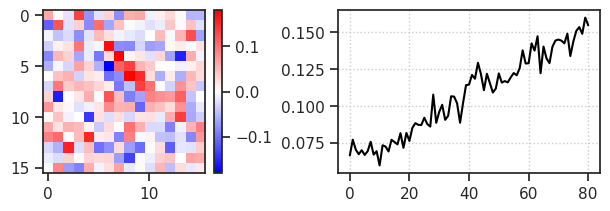

In [27]:
t_ker = tonp(uu[:, 0])
s_ker = tonp(vvh[0]).reshape(16, 16)

vminmax = np.abs(s_ker).max()

fig, axes = create_figure(1, 2, width_ratios=[1, 1.5])
im = axes[0].imshow(s_ker, cmap='bwr', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[0])
axes[1].plot(t_ker, color='k')
axes[1].grid()
plt.show()

In [28]:
show_movie(sta[neuron_i].reshape(-1, 16, 16))

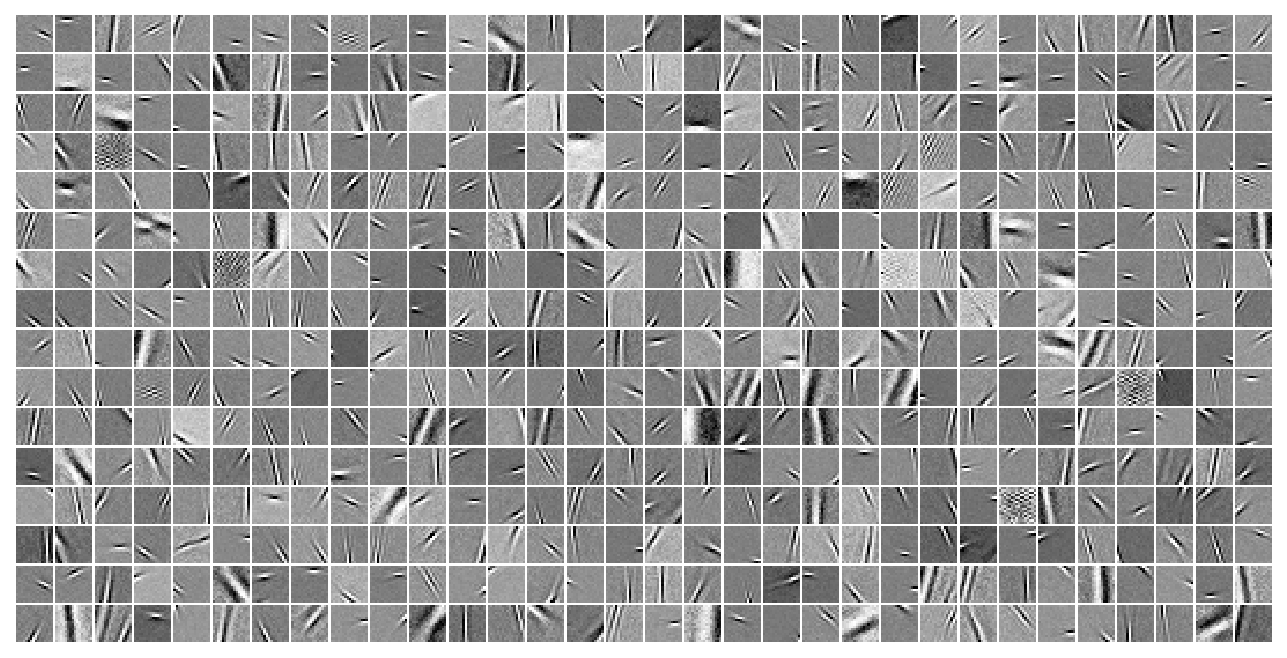

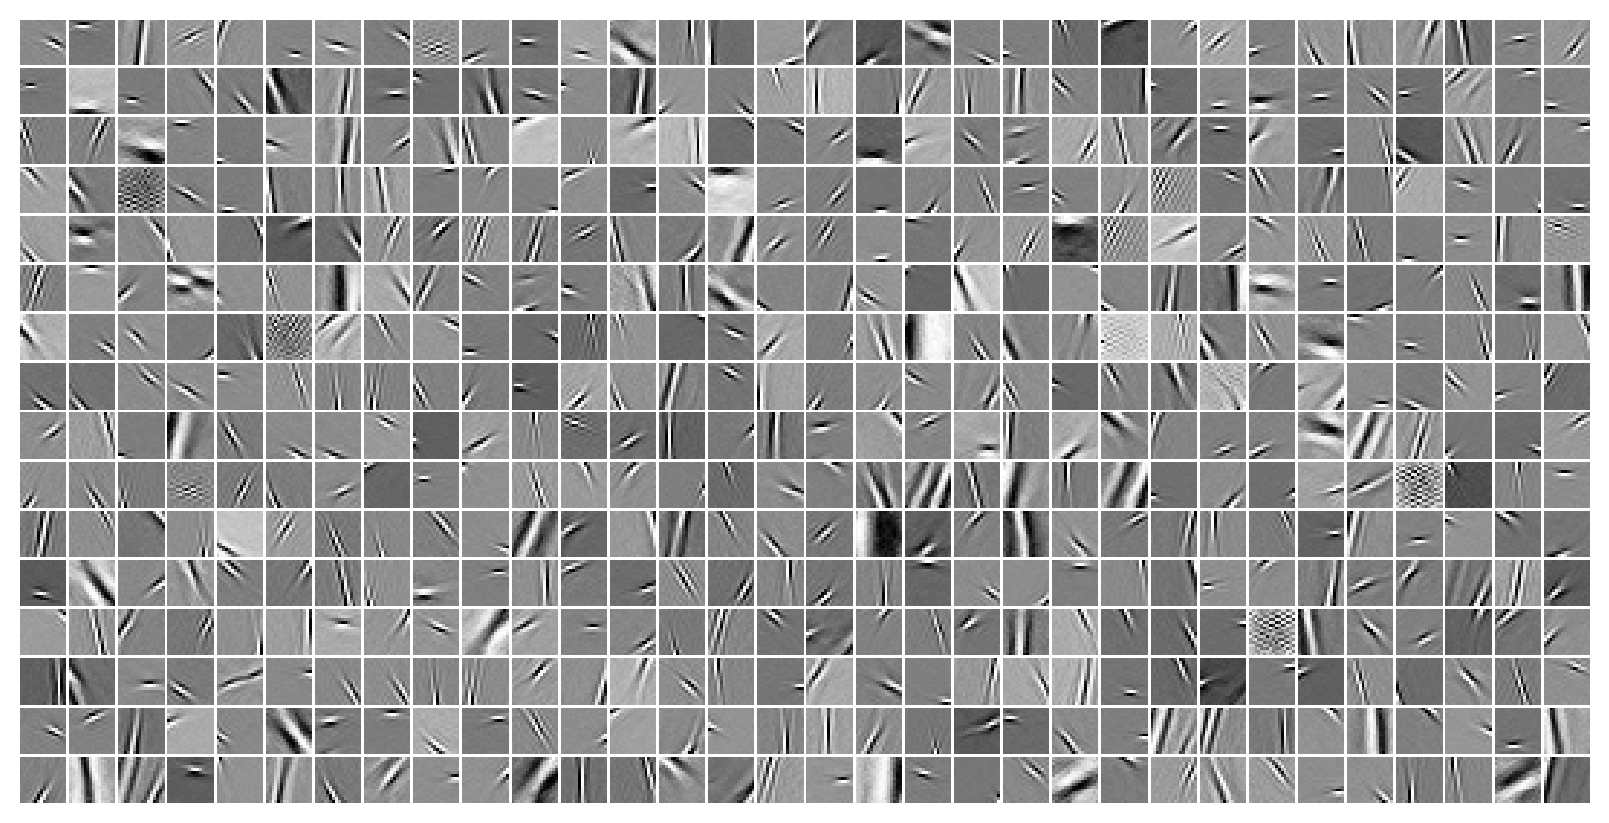

In [11]:
plot_weights(sta[:, -5, :].reshape(-1, 16, 16))
tr.model.show();

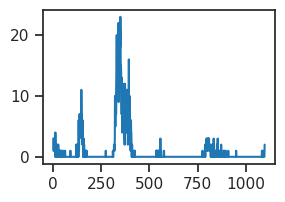

In [66]:
batch_i = 123
neuron_i = 71

plt.plot(tonp(output['samples'][batch_i, :, neuron_i]))
plt.show()

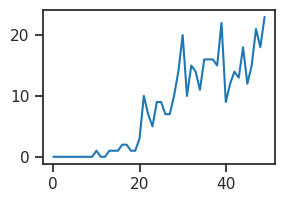

In [72]:
time_segment_i = 6
start = time_segment_i * feeder_kws['n_repeats']
end = (time_segment_i + 1) * feeder_kws['n_repeats']
intvl = range(start, min(end, total_timepoints))

x2p = tonp(output['samples'][batch_i, :, neuron_i])
plt.plot(x2p[intvl]);

## White noise feeder

In [15]:
feeder_kws = dict(
    npix=16,
    #
    n_repeats=10,
    batch_size=512,
    noise_sigma=1.0,
    #
    device=device,
    flatten=False,
    seed=0,
)
feeder = FEEDER_CLASSES['white-noise'](**feeder_kws)

In [16]:
frames = [feeder[t] for t in range(100)]
frames = torch.cat(frames, dim=1)
frames.shape

torch.Size([512, 100, 16, 16])

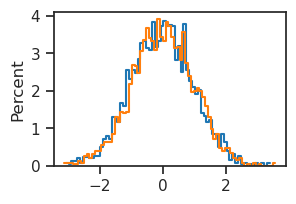

In [17]:
histplot(frames[-1].ravel(), stat='percent')
histplot(frames[0].ravel(), stat='percent');

In [18]:
show_movie(tonp(frames[-1].squeeze()), max_n=100, vmin=-2.0, vmax=2.0)